# Testes não paramétricos

## Testes para duas amostras independentes

Nestes testes, buscamos comparar duas populações representadas por suas respectivas amostras. Diferente dos testes para duas amostras emparelhadas, aqui não é necessário que as amostras sejam do mesmo tamanho. Dentre os testes para duas amostras independentes, podemos destacar o teste qui-quadrado (para variáveis nominais ou ordinais) e o teste de Mann-Whitney (para variáveis ordinais).

### Teste qui-quadrado para duas amostras independentes

O teste compara as frequências observadas em cada uma das células da tabela de contingência com as frequências esperadas. O teste $\chi^2$ para duas amostras independentes assume as seguintes hipóteses:

- $H_0$: não há diferença significativa entre as frequências observadas e esperadas
- $H_1$: há diferença significativa entre as frequências observadas e esperadas

A estatística $\chi^2$ mede, portanto, a discrepância entre uma tabela de contingência observada e uma tabela de contingência esperada, partindo da hipótese de que não há associação entre as categorias das duas variáveis estudadas. Se a distribuição de frequências observadas for exatamente igual à distribuição de frequências esperadas, o resultado da estatística $\chi^2$ será igual a zero. Assim, um valor baixo de $\chi^2$ indica independência entre as variáveis.

Exemplo: um estudo foi realizado com 200 indivíduos com o intuito de analisar o comportamento conjunto da variável *Operadora de plano de saúde* com a variável *Nível de satisfação*. Verifique se há associação entre as categorias das duas variáveis, considerando $\alpha = 5%$

In [1]:
import pandas as pd

DADOS = "./dados/plano_saude.csv"

df_saude = pd.read_csv(DADOS)

df_saude.head()

,operadora,satisfacao
0,Total Health,baixo
1,Total Health,baixo
2,Total Health,baixo
3,Total Health,baixo
4,Total Health,baixo


In [2]:
df_saude.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   operadora   200 non-null    object
 1   satisfacao  200 non-null    object
dtypes: object(2)
memory usage: 3.3+ KB


In [3]:
df_saude.describe()

,operadora,satisfacao
count,200,200
unique,3,3
top,Viva Vida,baixo
freq,72,96


In [4]:
pd.crosstab(df_saude["operadora"],df_saude['satisfacao'])

satisfacao,alto,baixo,medio
operadora,,,
Mena Saúde,4,24,32
Total Health,12,40,16
Viva Vida,16,32,24


In [6]:
pd.crosstab(
    df_saude["operadora"],
    df_saude['satisfacao'],
    margins= True,
    margins_name="Total",
    normalize="index").style.format("{:.1%}")

satisfacao,alto,baixo,medio
operadora,,,
Mena Saúde,6.7%,40.0%,53.3%
Total Health,17.6%,58.8%,23.5%
Viva Vida,22.2%,44.4%,33.3%
Total,16.0%,48.0%,36.0%


https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html

In [7]:
from scipy.stats import chi2_contingency
chi2_contingency(pd.crosstab(df_saude["operadora"],df_saude['satisfacao']))

Chi2ContingencyResult(statistic=np.float64(15.860566448801741), pvalue=np.float64(0.003212084698153722), dof=4, expected_freq=array([[ 9.6 , 28.8 , 21.6 ],
       [10.88, 32.64, 24.48],
       [11.52, 34.56, 25.92]]))

Para o nível de confiança de 95%, como P = 0,003< 0,05, devemos rejeitar a hipótese nula, o que nos permite
concluir, ao nível de confiança de 95%, que há associação entre as categorias das variáveis, isto é, as frequências
observadas são diferentes das frequências esperadas em pelo menos um par de categorias.

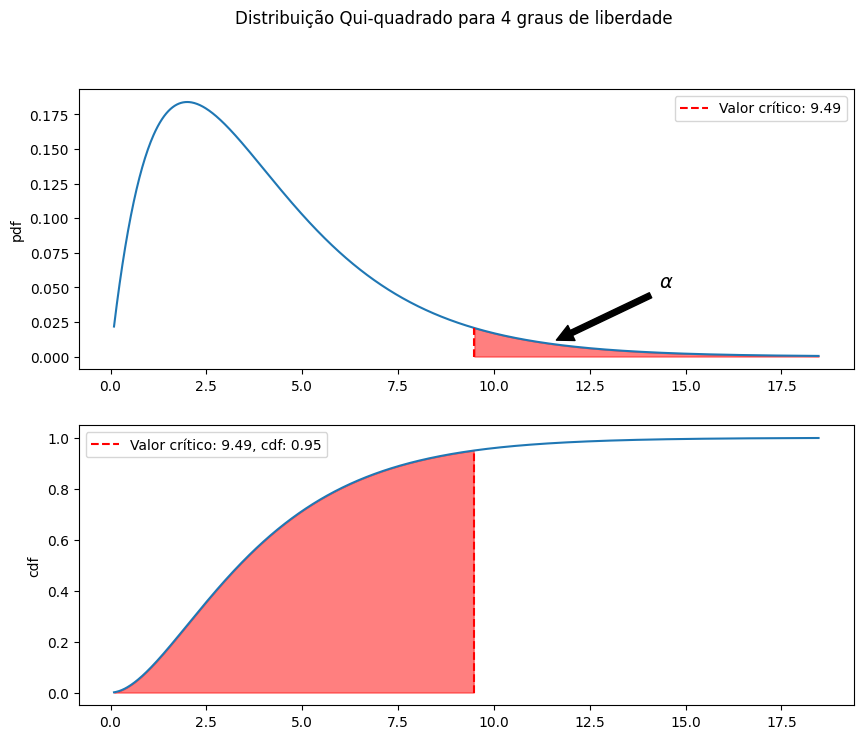

In [9]:
from graficos import plot_chi2

plot_chi2(4,0.05)